In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def load_data(file_name: str) -> pd.DataFrame:
    """
    Loads the raw SEN Excel file.

    Returns:
        pandas DataFrame containing the raw SEN data
    """
    return pd.read_excel(file_name)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleans and prepares the SEN dataset.

    - parses the Data column as datetime
    - converts MW columns to numeric values
    - removes rows with invalid dates
    - removes duplicates
    - sorts observations chronologically
    """

    df = df.copy()

    df["Data"] = pd.to_datetime(
        df["Data"],
        dayfirst=True,
        errors="coerce"
    )

    numeric_columns = df.columns.drop("Data")

    for column in numeric_columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.dropna(subset=["Data"])
    df = df.drop_duplicates()
    df = df.sort_values("Data").reset_index(drop=True)

    return df

def save_data(df: pd.DataFrame, file_name: str) -> None:
    """
    Saves the cleaned SEN dataset as CSV.
    """
    df.to_csv(file_name, index=False)

In [ ]:
raw_df = load_data("../data/raw/Grafic_SEN_2025.xlsx")

df = clean_data(raw_df)

df["Ora"] = df["Data"].dt.hour

save_data(
    df,
    "../data/processed/sen_2025_clean.csv"
)

c:\Users\albaa\Desktop\my stuff\Lucru\MBK Energy\mbk-sen-eda\.venv\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


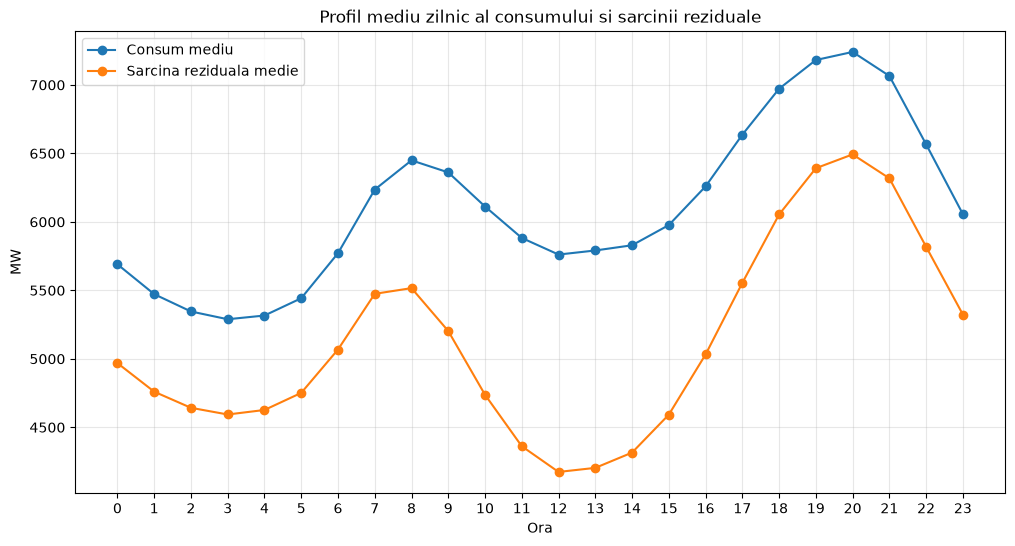

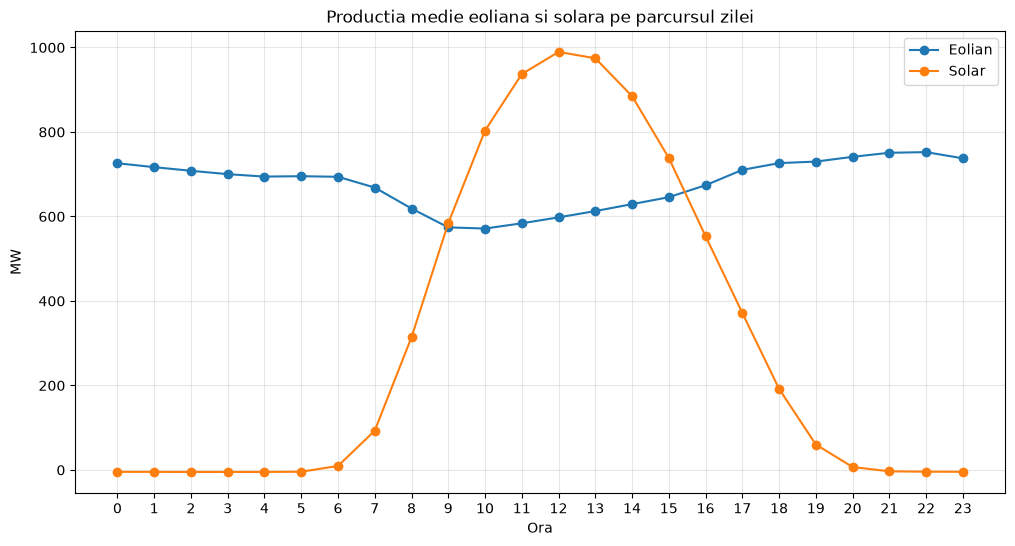

Consum mediu: 6113 MW
Sarcina reziduala medie: 5124 MW
Pondere reziduala: 83.8%
Contributie eolian + solar: 16.2%
Minim mediu al sarcinii reziduale la pranz: 4174 MW, la ora 12
Maxim mediu al sarcinii reziduale seara: 6493 MW, la ora 20


In [ ]:
# Q1 Cum arată sarcina reziduală (consum total − eolian − solar) pe parcursul zilei și cât trebuie completat de producția convențională?

# Sarcina ramasa dupa fiecare tip de productie
df["RezidualaSolar[MW]"] = (
    df["Consum[MW]"]
    - df["Foto[MW]"]
)

df["RezidualaEolian[MW]"] = (
    df["Consum[MW]"]
    - df["Eolian[MW]"]
)

df["SarcinaReziduala[MW]"] = (
    df["Consum[MW]"]
    - df["Eolian[MW]"]
    - df["Foto[MW]"]
)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu pe fiecare ora a zilei
hourly_profile = df.groupby("Ora")[
    ["Consum[MW]", "SarcinaReziduala[MW]", "Eolian[MW]", "Foto[MW]"]
].mean()

# Ponderea din consum care ramane de acoperit dupa eolian si solar
hourly_profile["PondereReziduala[%]"] = (
    hourly_profile["SarcinaReziduala[MW]"]
    / hourly_profile["Consum[MW]"] * 100
)

hourly_profile["ContributieEolianSolar[%]"] = (
    100 - hourly_profile["PondereReziduala[%]"]
)

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Indicatorii generali pentru 2025

consumption_mean = df["Consum[MW]"].mean()
residual_mean = df["SarcinaReziduala[MW]"].mean()

# Raportul dintre sarcina reziduala totala si consumul total
residual_share = (
    df["SarcinaReziduala[MW]"].sum()
    / df["Consum[MW]"].sum() * 100
)

renewable_share = 100 - residual_share


print(f"Consum mediu: {consumption_mean:.0f} MW")
print(f"Sarcina reziduala medie: {residual_mean:.0f} MW")
print(f"Pondere reziduala: {residual_share:.1f}%")
print(f"Contributie eolian + solar: {renewable_share:.1f}%")

# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

midday_profile = hourly_profile.loc[11:15]
evening_profile = hourly_profile.loc[17:21]

midday_min_hour = midday_profile["SarcinaReziduala[MW]"].idxmin()
midday_min_value = midday_profile["SarcinaReziduala[MW]"].min()

evening_max_hour = evening_profile["SarcinaReziduala[MW]"].idxmax()
evening_max_value = evening_profile["SarcinaReziduala[MW]"].max()

print(
    f"Minim mediu al sarcinii reziduale la pranz: "
    f"{midday_min_value:.0f} MW, la ora {midday_min_hour}"
)

print(
    f"Maxim mediu al sarcinii reziduale seara: "
    f"{evening_max_value:.0f} MW, la ora {evening_max_hour}"
)

# Concluzie Q1:
Profilul mediu zilnic arată că sarcina reziduală variază semnificativ pe parcursul zilei. În intervalul de prânz, aceasta scade, atingând un minim mediu de aproximativ 4174 MW la ora 12, pe fondul contribuției mai ridicate a producției eoliene și solare. Spre seară, necesarul rămas de acoperit crește, atingând aproximativ 6493 MW la ora 20. În ansamblul observațiilor din 2025, sarcina reziduală medie a fost de aproximativ 5124 MW, reprezentând 83.8% din consum, ceea ce corespunde unei contribuții medii cumulate a producției eoliene și solare de aproximativ 16.2%. Prin urmare, necesarul rămas pentru restul sistemului este mai redus în jurul prânzului și mai ridicat în perioada de seară.

Cea mai mare crestere medie apare in jurul orei 17: 114 MW / ~10 min
Cea mai mare scadere medie apare in jurul orei 22: -101 MW / ~10 min

Cea mai mare crestere observata in 2025: 1394 MW / ~10 min, la 2025-07-25 17:49:04
Cea mai mare scadere observata in 2025: -1218 MW / ~10 min, la 2025-12-25 17:13:14

Top 10 ramp-up:
                     Data  Ora  Rampa[MW]
29835 2025-07-25 17:49:04   17     1394.0
51848 2025-12-25 17:23:41   17     1370.0
24908 2025-06-21 22:22:54   22      964.0
50788 2025-12-18 08:05:32    8      595.0
49014 2025-12-05 23:48:31   23      521.0
10747 2025-03-16 08:19:38    8      505.0
39166 2025-09-28 15:34:32   15      483.0
32856 2025-08-15 18:06:09   18      479.0
26050 2025-06-29 19:07:19   19      477.0
32303 2025-08-11 18:07:08   18      475.0

Top 10 ramp-down:
                     Data  Ora  Rampa[MW]
51847 2025-12-25 17:13:14   17    -1218.0
29834 2025-07-25 17:39:12   17    -1169.0
24907 2025-06-21 22:13:02   22    -1061.0
49016 2025-12-06 00:08:23    

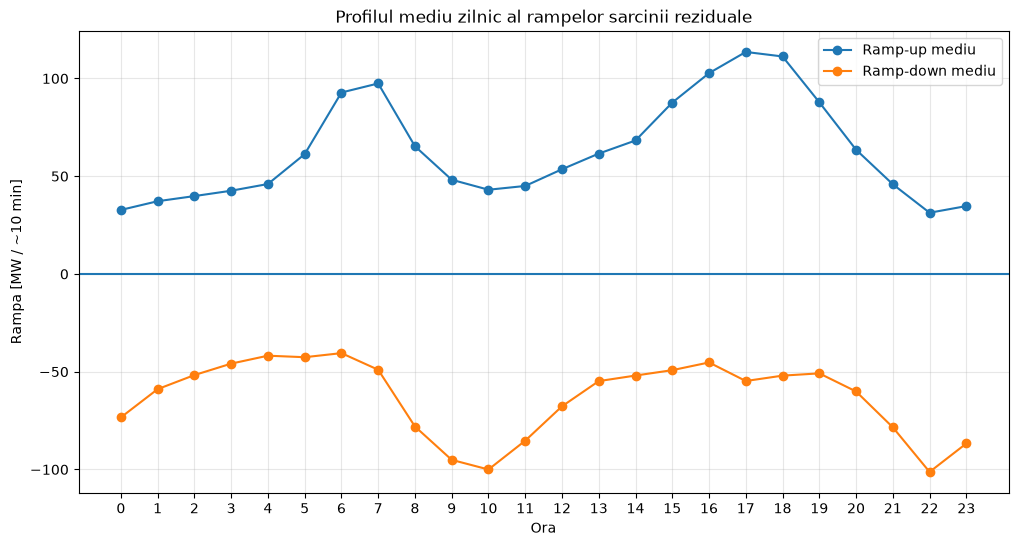

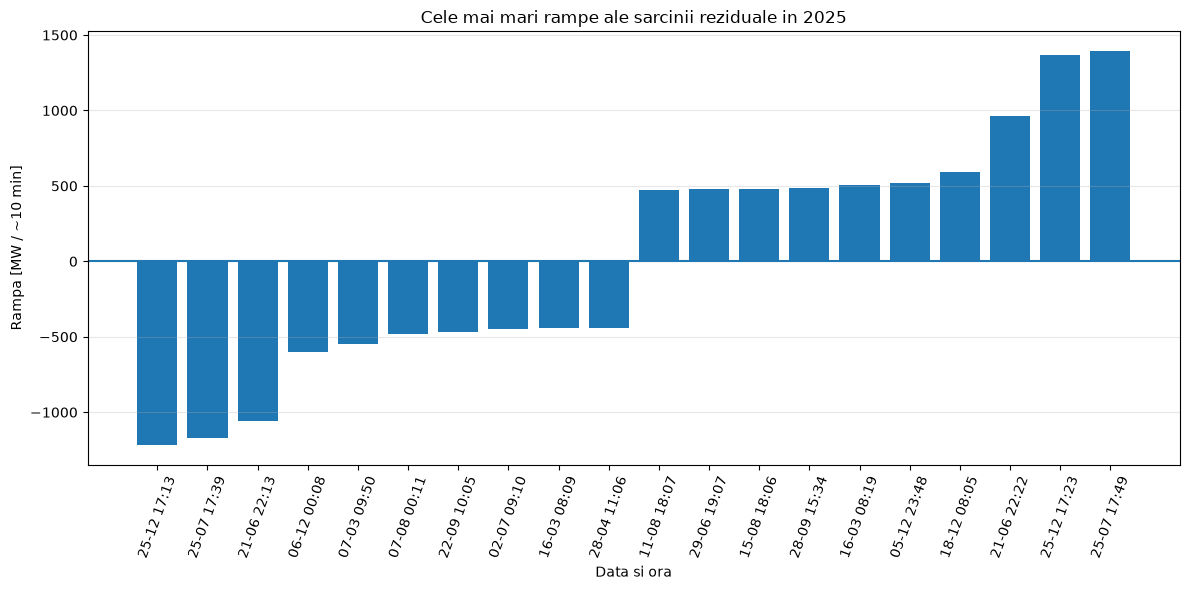

In [11]:
# Q2 - Care sunt cele mai mari rampe și la ce ore apar?

# Calculam intervalul dintre observatii, in minute
df["IntervalMinute"] = (
    df["Data"].diff().dt.total_seconds() / 60
)

# Rampa = modificarea sarcinii reziduale fata de observatia anterioara
df["Rampa[MW]"] = (
    df["SarcinaReziduala[MW]"]
    - df["SarcinaReziduala[MW]"].shift(1)
)

# Pastram doar observatiile aflate la aproximativ 10 minute distanta,
# pentru ca rampele sa fie comparabile
df_rampe = df[
    (df["IntervalMinute"] >= 9)
    & (df["IntervalMinute"] <= 11)
].copy()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Profilul mediu al rampelor pe fiecare ora a zilei

# Separarea este necesara pentru ca ramp-up si ramp-down
# sa nu se anuleze atunci cand calculam media
ramp_up = df_rampe[df_rampe["Rampa[MW]"] > 0]
ramp_down = df_rampe[df_rampe["Rampa[MW]"] < 0]

hourly_ramp_up = (
    ramp_up.groupby("Ora")["Rampa[MW]"].mean()
)

hourly_ramp_down = (
    ramp_down.groupby("Ora")["Rampa[MW]"].mean()
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Momente relevante ale profilului zilnic

# Ora cu cea mai puternica crestere medie
max_avg_ramp_up_hour = hourly_ramp_up.idxmax()
max_avg_ramp_up_value = hourly_ramp_up.max()

# Ora cu cea mai puternica scadere medie
max_avg_ramp_down_hour = hourly_ramp_down.idxmin()
max_avg_ramp_down_value = hourly_ramp_down.min()

print(
    f"Cea mai mare crestere medie apare in jurul orei "
    f"{max_avg_ramp_up_hour}: "
    f"{max_avg_ramp_up_value:.0f} MW / ~10 min"
)

print(
    f"Cea mai mare scadere medie apare in jurul orei "
    f"{max_avg_ramp_down_hour}: "
    f"{max_avg_ramp_down_value:.0f} MW / ~10 min"
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Cele mai extreme rampe observate in 2025

largest_ramp_up = df_rampe.nlargest(10, "Rampa[MW]")
largest_ramp_down = df_rampe.nsmallest(10, "Rampa[MW]")

# Cea mai mare crestere din intregul an
max_ramp_up = largest_ramp_up.iloc[0]

# Cea mai mare scadere din intregul an
max_ramp_down = largest_ramp_down.iloc[0]

print()

print(
    f"Cea mai mare crestere observata in 2025: "
    f"{max_ramp_up['Rampa[MW]']:.0f} MW / ~10 min, "
    f"la {max_ramp_up['Data']}"
)

print(
    f"Cea mai mare scadere observata in 2025: "
    f"{max_ramp_down['Rampa[MW]']:.0f} MW / ~10 min, "
    f"la {max_ramp_down['Data']}"
)

print()

print("Top 10 ramp-up:")
print(
    largest_ramp_up[[
        "Data",
        "Ora",
        "Rampa[MW]"
    ]]
)

print()

print("Top 10 ramp-down:")
print(
    largest_ramp_down[[
        "Data",
        "Ora",
        "Rampa[MW]"
    ]]
)


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 1 - Profilul mediu zilnic al rampelor

plt.figure(figsize=(12, 6))

plt.plot(
    hourly_ramp_up.index,
    hourly_ramp_up.values,
    marker="o",
    label="Ramp-up mediu"
)

plt.plot(
    hourly_ramp_down.index,
    hourly_ramp_down.values,
    marker="o",
    label="Ramp-down mediu"
)

plt.axhline(0)

plt.xlabel("Ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Profilul mediu zilnic al rampelor sarcinii reziduale")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# Grafic 2 - Cele mai extreme rampe observate in 2025

top_ramps = pd.concat([
    largest_ramp_down,
    largest_ramp_up
]).sort_values("Rampa[MW]")

plt.figure(figsize=(12, 6))

plt.bar(
    top_ramps["Data"].dt.strftime("%d-%m %H:%M"),
    top_ramps["Rampa[MW]"]
)

plt.axhline(0)

plt.xlabel("Data si ora")
plt.ylabel("Rampa [MW / ~10 min]")
plt.title("Cele mai mari rampe ale sarcinii reziduale in 2025")

plt.xticks(rotation=70)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()


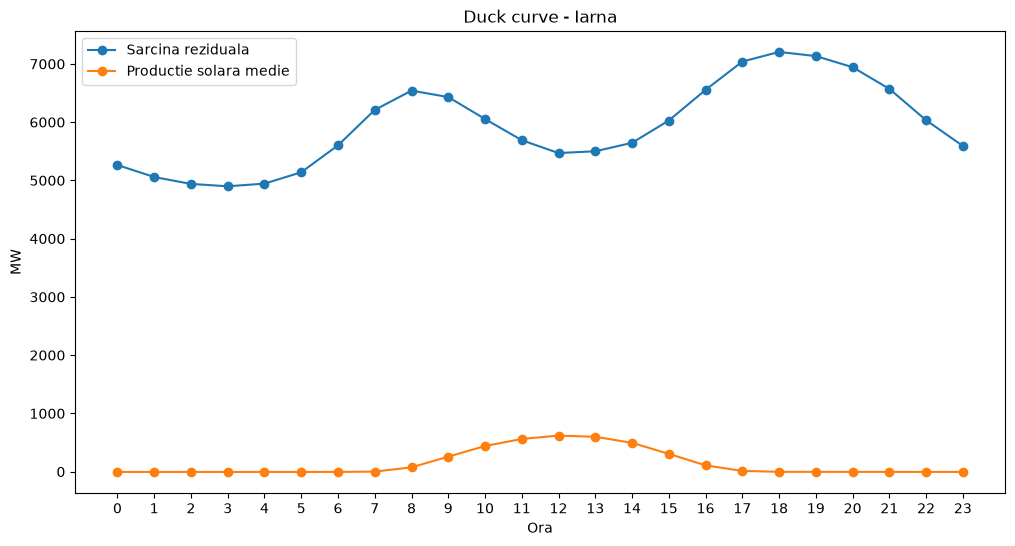

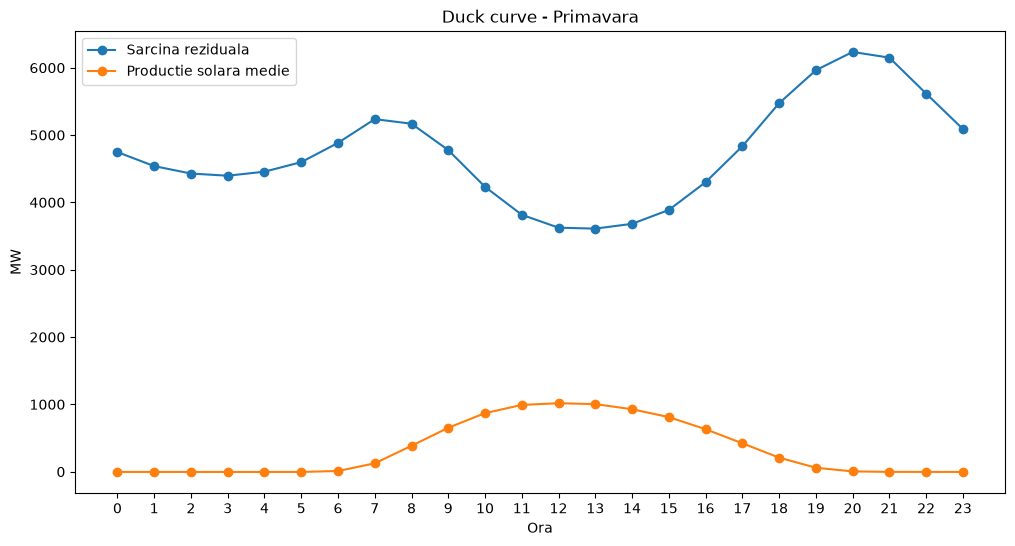

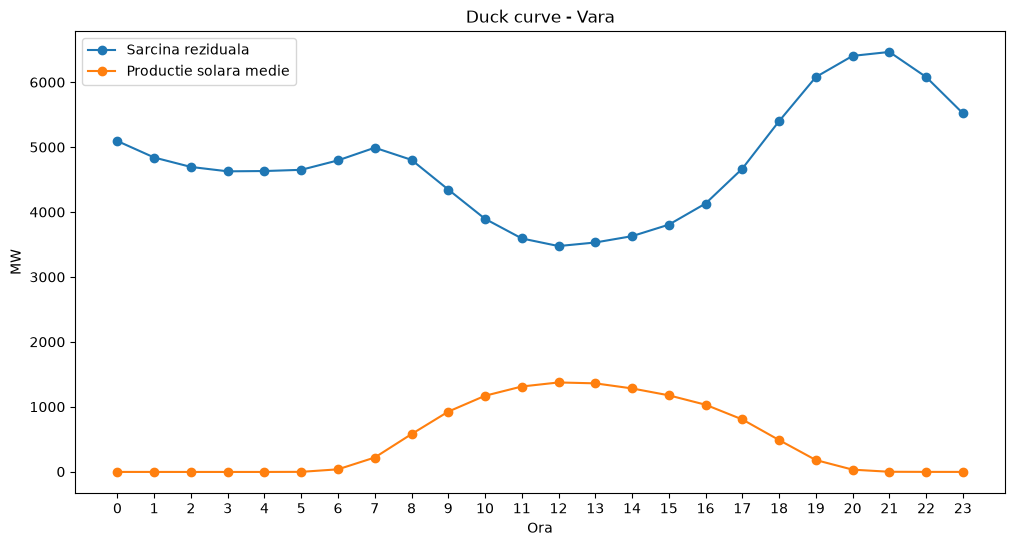

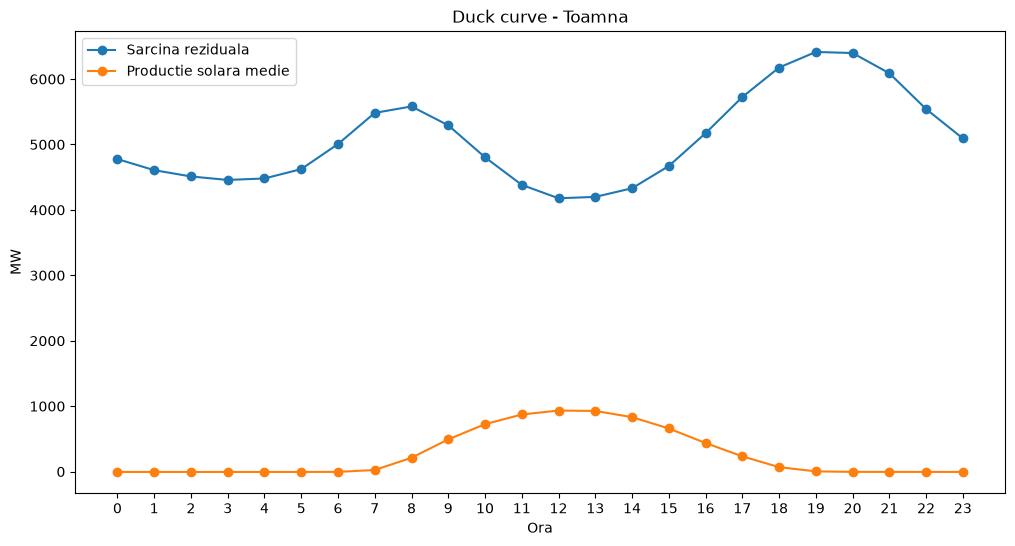

In [12]:
# Q3 Există momente cu „duck curve” (scădere la prânz din cauza solarului, urcare bruscă seara)?

# Fac 4 grafuri pentru fiecare anotimp, iar pentru un anotimp in fiecare zi vad cand scade reziuduala si cand creste brusc,
# comparat cu energia solara. Practic pentru fiecare zi va fi peak foto gap rezidu si gap foto peak rezidu.

df["Anotimp"] = df["Data"].dt.month.map({
    12: "Iarna",
    1: "Iarna",
    2: "Iarna",
    3: "Primavara",
    4: "Primavara",
    5: "Primavara",
    6: "Vara",
    7: "Vara",
    8: "Vara",
    9: "Toamna",
    10: "Toamna",
    11: "Toamna"
})

hourly_foto = df.groupby(["Anotimp", "Ora"])[["SarcinaReziduala[MW]", "Foto[MW]"]].mean()

sezoane = ["Iarna", "Primavara", "Vara", "Toamna"]

for sezon in sezoane:
    sezon_data = hourly_foto.loc[sezon]

    plt.figure(figsize=(12, 6))

    plt.plot(
        sezon_data.index,
        sezon_data["SarcinaReziduala[MW]"],
        marker="o",
        label="Sarcina reziduala"
    )

    plt.plot(
        sezon_data.index,
        sezon_data["Foto[MW]"],
        marker="o",
        label="Productie solara medie"
    )

    plt.xlabel("Ora")
    plt.ylabel("MW")
    plt.title(f"Duck curve - {sezon}")
    plt.xticks(range(24))
    plt.legend()
    plt.show()

# 1. La prânz solarul ajunge la un nivel ridicat / maxim.
#                          ↓
# 2. În aceeași zonă orară sarcina reziduală are un minim local.
#                          ↓
# 3. Spre seară solarul scade.
#                          ↓
# 4. Sarcina reziduală crește din nou semnificativ.
#                          ↓
# 5. Creșterea de seară este suficient de rapidă
#    → o susții cu rampele / Q2.

# Pentru fiecare anotimp construiesc profilul mediu pe ore al
# sarcinii reziduale si al productiei solare.
# Verific daca maximul solar de la pranz coincide cu un minim
# al sarcinii reziduale si daca aceasta creste rapid spre seara.

# PRÂNZ, 11–15
# - valoarea maximă Foto
# - ora maximului Foto
# - valoarea minimă SarcinăReziduală
# - ora minimului SarcinăReziduală

# DIMINEAȚĂ, 6–10
# - nivelul maxim / reprezentativ al rezidualei

# SEARĂ, 17–21
# - nivelul maxim al rezidualei

# DIFERENȚE
# - scădere dimineață → prânz
# - creștere prânz → seară